#<font color= 'Blue'><font size= 18> Assignment 2</font></font>
---
1. High level statistics of the dataset: number of points, numer of features, number of classes, data-points per class.
2. Explain our objective.
3. Perform Univaraite analysis(PDF, CDF, Boxplot, Voilin plots) to understand which features are useful towards classification.
4. Perform Bi-variate analysis (scatter plots, pair-plots) to see if combinations of features are useful in classfication.
5. Write your observations as crisply and unambigously as possible. Always quantify your results.
---

In [ ]:
#Mount CSV file in drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [ ]:
#Column Names
column_name = ['age', 'optYear', 'axilNodes', 'status']

#Reading Data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Csv_file/haberman.csv', header=None, names=column_name)
df.keys()

Index(['age', 'optYear', 'axilNodes', 'status'], dtype='object')

In [ ]:
#Inspect the feature data shape
df.drop(columns=['status']).shape

(306, 3)

In [ ]:
#Inspect the target shape
targetArry= np.array(df['status'])
targetArry.shape

(306,)

In [ ]:
#Inspect target labels:
targetArry

array([1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1,

In [ ]:
#Check the Feature names:
df.drop(columns=['status']).columns

Index(['age', 'optYear', 'axilNodes'], dtype='object')

In [ ]:
# Raw Data
sp_df = pd.DataFrame(df)
sp_df.head()

,age,optYear,axilNodes,status
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


In [ ]:
#Info and description
sp_df.info()
sp_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        306 non-null    int64
 1   optYear    306 non-null    int64
 2   axilNodes  306 non-null    int64
 3   status     306 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


,age,optYear,axilNodes,status
count,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,1.264706
std,10.803452,3.249405,7.189654,0.441899
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [ ]:
#Data points in target
sp_df['status'].value_counts()

,count
status,
1,225
2,81


In [ ]:
#Checking for null values
sp_df.isnull().sum()

,0
age,0
optYear,0
axilNodes,0
status,0


In [ ]:
data = sp_df.drop(columns=["status"])

# <font color= 'turquoise'>Bar Plot:</font>

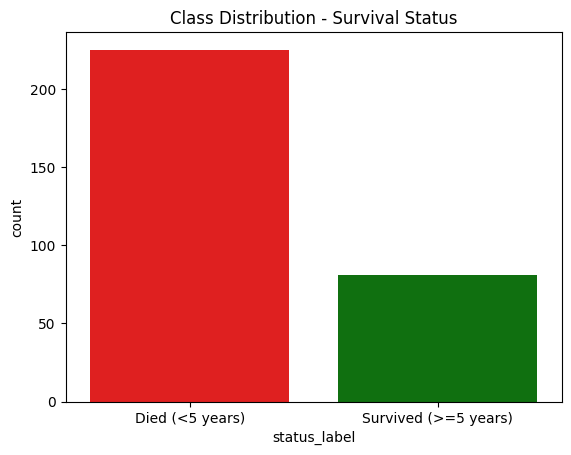

In [ ]:
#Bar Plot
df["status_label"] = df["status"].map({
    1: "Died (<5 years)",
    2: "Survived (>=5 years)"
})

sns.countplot(
    x="status_label",
    hue="status_label",
    data=df,
    palette=["red", "green"],
    legend=False
)

plt.title("Class Distribution - Survival Status")
plt.show()


# <font color= 'turquoise'>Histogram:</font>

<Figure size 500x400 with 0 Axes>

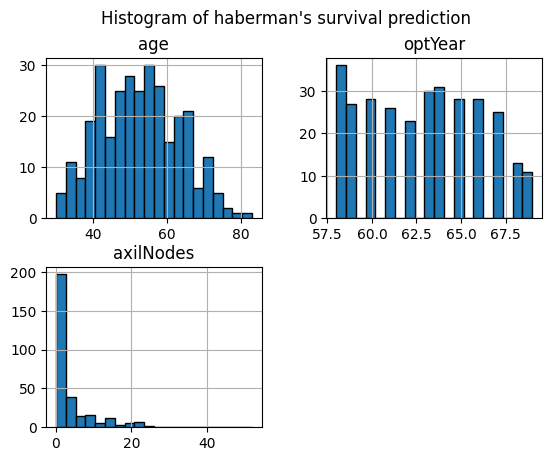

In [ ]:
#Figure
plt.figure(figsize=(5, 4))

#Histogram
data.hist(bins=20, edgecolor='black')

plt.suptitle("Histogram of haberman's survival prediction", fontsize=12)
plt.show()

# <font color= 'turquoise'>Histogram with KDE curve (Distribution Analysis):</font>

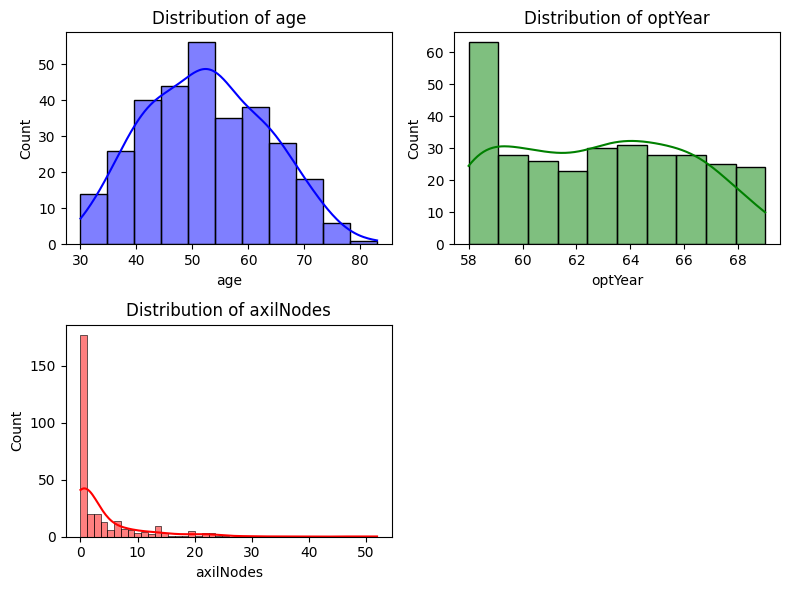

In [ ]:
#Define four different colors
colors = ['blue', 'green', 'red', 'violet']

plt.figure(figsize=(8, 6))

##Loop to plot all the features's histogram with KDE
for i, (data, color) in enumerate(zip(data, colors), 1):
    plt.subplot(2, 2, i)
    sns.histplot(sp_df[data], kde=True, color=color)
    plt.title(f'Distribution of {data}')

plt.tight_layout()
plt.show()

# <font color= 'turquoise'>Overlaid Histograms:</font>

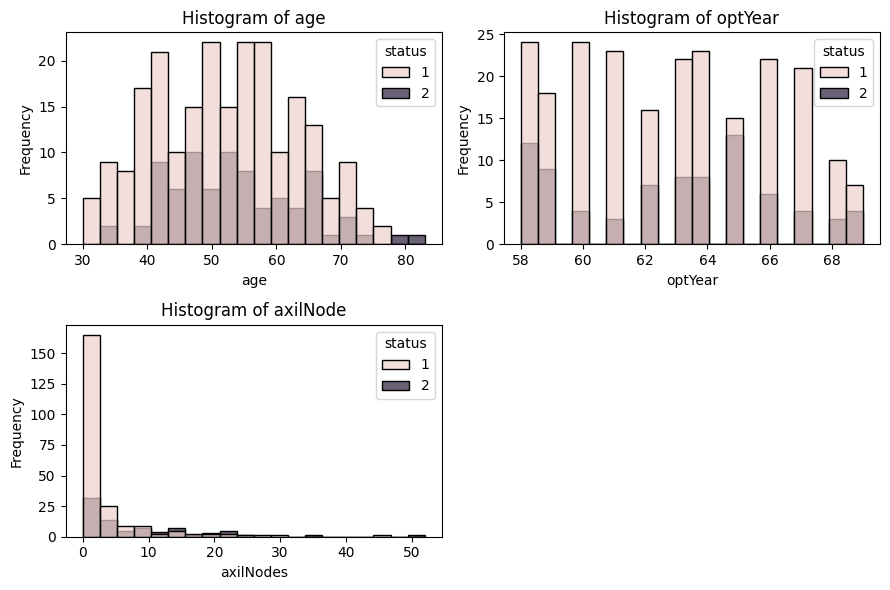

In [ ]:
#Select data types of the features
features = sp_df.drop(columns= ["status"])

##Set titles of the histograms:
titles = ['Histogram of age',
          'Histogram of optYear',
          'Histogram of axilNode'
        ]

##Declare figure size
plt.figure(figsize=(9, 6))

##Plot overlaid histograms for each features one by one
for i, (feature, title) in enumerate(zip(features, titles), 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=sp_df,
        x=feature,
        hue='status',
        multiple='layer',     # overlapping bars
        bins=20,
        edgecolor='black',
        alpha=0.7
    )
    plt.title(title, fontsize=12)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# <font color= 'turquoise'>Multivariate Box Plot (Feature-wise Comparison):</font>

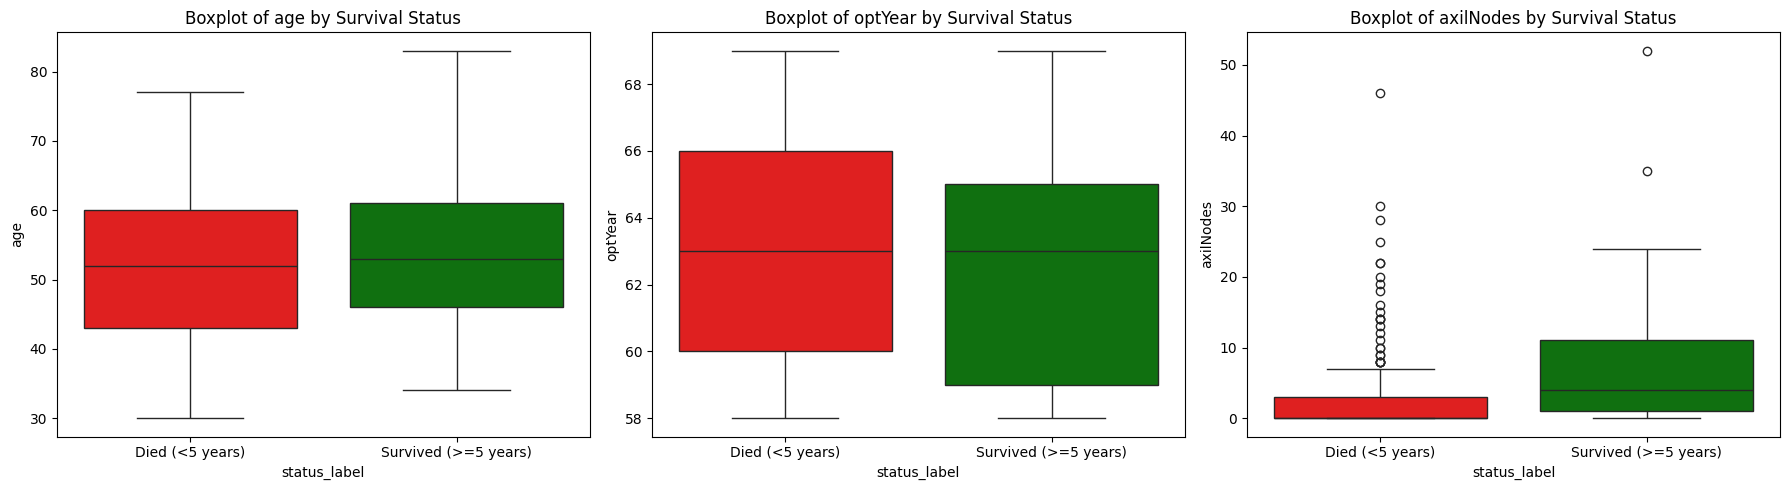

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ["age", "optYear", "axilNodes"]

df["status_label"] = df["status"].map({
    1: "Died (<5 years)",
    2: "Survived (>=5 years)"
})

for i, feature in enumerate(features):
    sns.boxplot(
        x="status_label",
        y=feature,
        hue="status_label",
        data=df,
        ax=axes[i],
        palette=["red", "green"],
        legend=False
    )
    axes[i].set_title(f"Boxplot of {feature} by Survival Status")

plt.tight_layout()
plt.show()



# <font color= 'turquoise'>Pair Plot Analysis:</font>

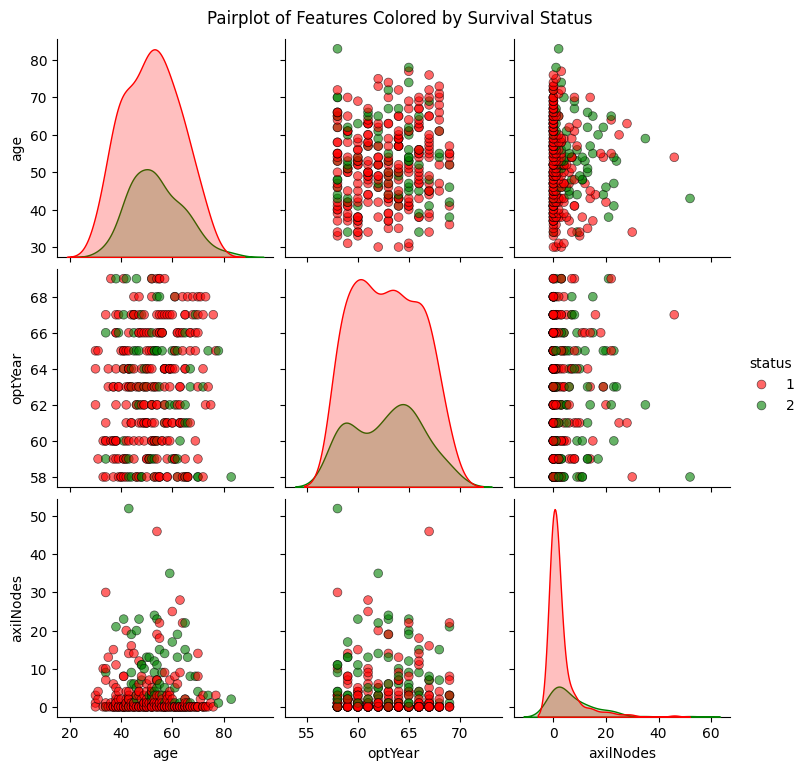

In [ ]:
##Perform pair plot using sns.pairplot()
sns.pairplot(sp_df,  hue="status", palette=["red", "green"], diag_kind="kde",
             plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'})
plt.suptitle("Pairplot of Features Colored by Survival Status", y=1.02)
plt.show()

# <font color= 'turquoise'>Heat Map:</font>

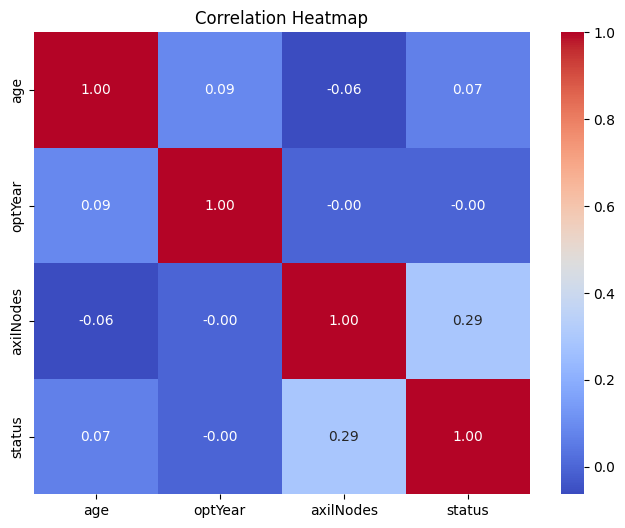

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

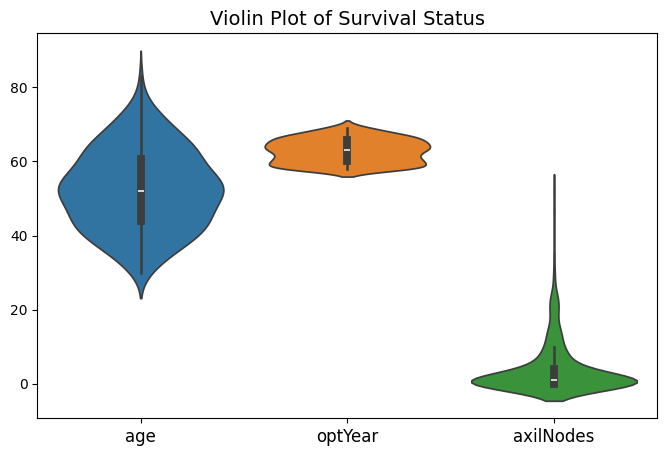

In [ ]:
##Violin plot
plt.figure(figsize=(8, 5))

sns.violinplot(data=sp_df.iloc[:, :-1])

plt.title("Violin Plot of Survival Status", fontsize=14)
plt.xticks(fontsize=12)   # change x-tick label size
plt.show()

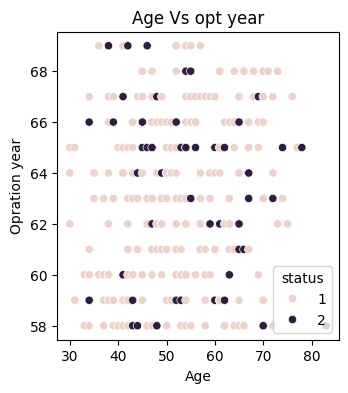

In [ ]:
# Create a figure with two sub-figures side-by-side:
plt.figure(figsize=(8, 4))

# ----- 1st subplot: Age vs. Opt year ---------
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='age',
    y='optYear',
    hue='status',
    data=sp_df)
plt.title('Age Vs opt year')
plt.xlabel('Age')
plt.ylabel('Opration year')
plt.legend(title='status')

# ----- 2nd subplot:
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='optYear',
    y='age',
    hue='status',
    data=sp_df)
plt.title('Opt year Vs Age')
plt.xlabel('Age')
plt.ylabel('Opration year')
plt.legend(title='status')